Dataset loaded successfully. Shape: (122, 24)

First 5 rows:
               Movie_Title  Release Year             Genre  \
0  Avengers: Age of Ultron          2015  Action/Adventure   
1           Jurassic World          2015  Action/Adventure   
2                Furious 7          2015  Action/Adventure   
3   Avengers: Infinity War          2018  Action/Adventure   
4        Avengers: Endgame          2019  Action/Adventure   

   Production Budget ($M)  WW Box Office Gross ($M)  \
0                     365                      1405   
1                     150                      1670   
2                     190                      1516   
3                     316                      2048   
4                     356                      2798   

   Franchise/Sequel (1=Yes, 0=No)         Director          Lead Star  \
0                               1      Joss Whedon  Robert Downey Jr.   
1                               1  Colin Trevorrow        Chris Pratt   
2               

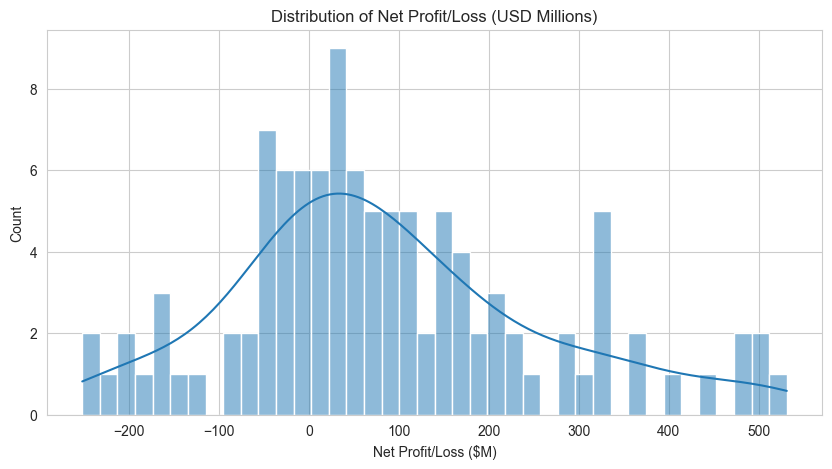

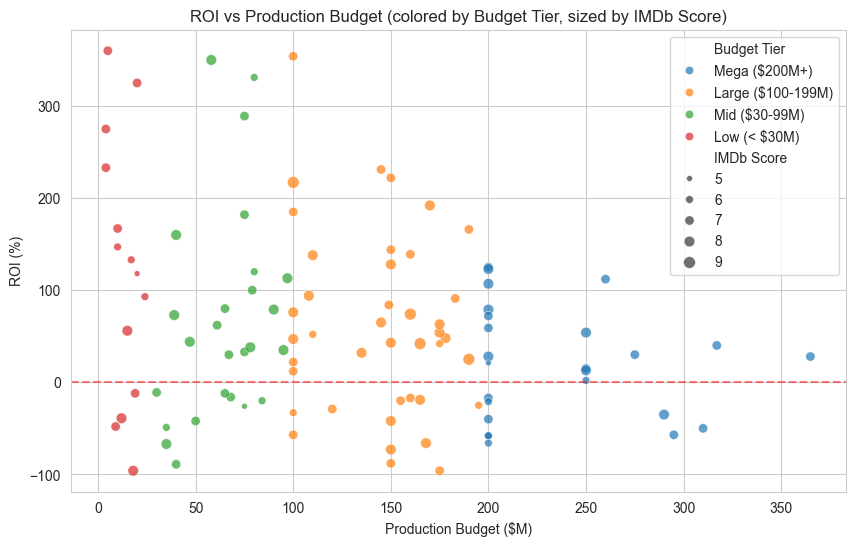

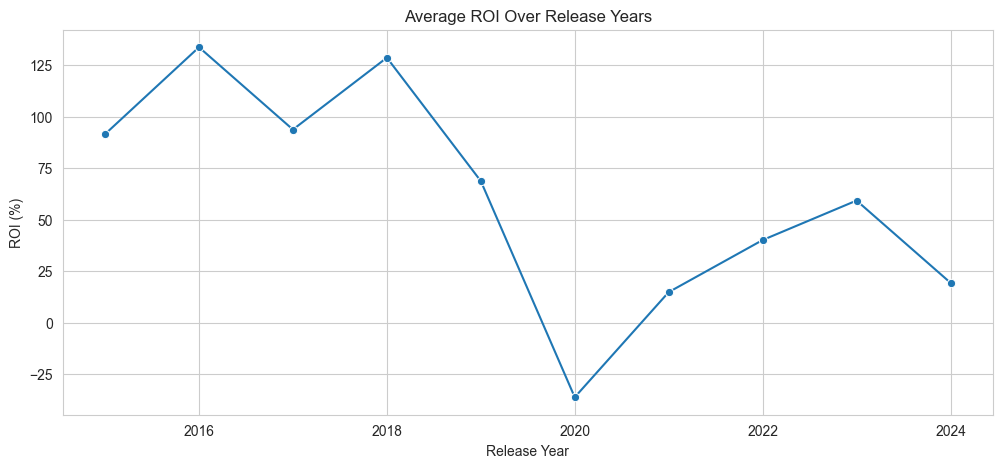

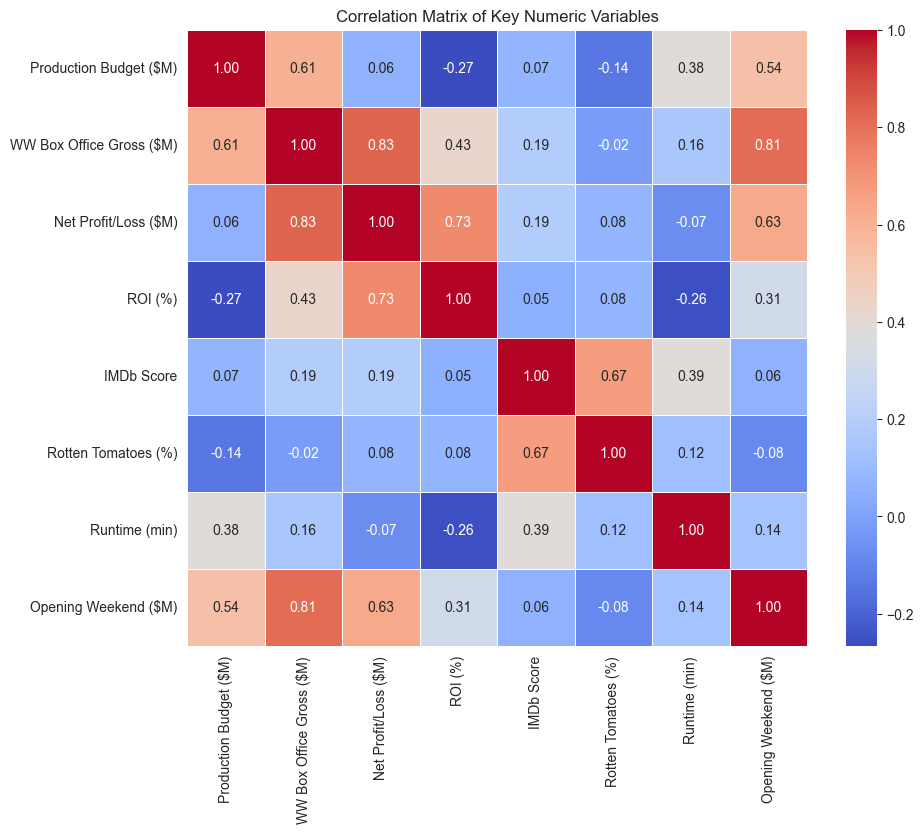

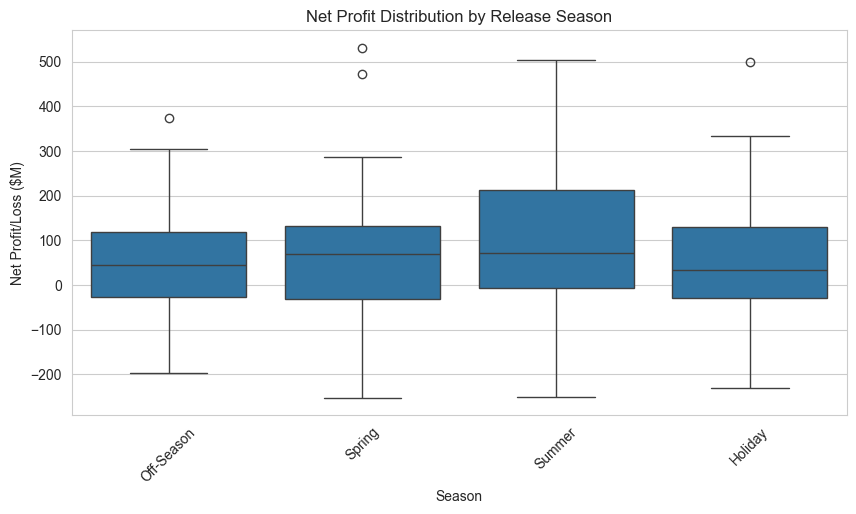

In [16]:

# 1. IMPORTS & DATA LOADING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, widgets, VBox, HBox, Output
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


df = pd.read_csv("/Users/sasidharmamidi/Documents/movie_boxoffice_dataset/Movie Dataset-Table 1.csv")

print("Dataset loaded successfully. Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
df.info()


# 2. DATA CLEANING & PREPARATION


df_clean = df.copy()

df_clean.columns = df_clean.columns.str.strip()

numeric_cols = [
    'Production Budget ($M)', 'WW Box Office Gross ($M)', 'Sequel Number',
    'Streaming Days After Release', 'Marketing Budget Est. ($M)',
    'Total Cost Est. ($M)', 'Net Profit/Loss ($M)', 'ROI (%)',
    'Opening Weekend Ratio (%)', 'Runtime (min)', 'IMDb Score',
    'Rotten Tomatoes (%)', 'Opening Weekend ($M)'
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print(df_clean.isnull().sum())

df_clean = df_clean.dropna(subset=[
    'Net Profit/Loss ($M)', 
    'Production Budget ($M)', 
    'ROI (%)'
])

df_clean.fillna({
    'Marketing Budget Est. ($M)': df_clean['Marketing Budget Est. ($M)'].median(),
    'Runtime (min)': df_clean['Runtime (min)'].median(),
    'IMDb Score': df_clean['IMDb Score'].mean(),
    'Rotten Tomatoes (%)': df_clean['Rotten Tomatoes (%)'].mean()
}, inplace=True)

df_clean = df_clean.drop_duplicates()

df_clean['MPAA Rating'] = df_clean['MPAA Rating'].str.upper().str.strip()

df_clean['MPAA Rating'] = df_clean['MPAA Rating'].replace({
    'PG13': 'PG-13',
    'PG 13': 'PG-13',
    'RATED R': 'R'
})

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['Net Profit/Loss ($M)', 'Production Budget ($M)', 'ROI (%)']:
    df_clean = remove_outliers_iqr(df_clean, col)

df_clean['Profit Category'] = pd.cut(
    df_clean['Net Profit/Loss ($M)'],
    bins=[-np.inf, 0, 100, np.inf],
    labels=['Loss', 'Average', 'Hit']
)

print(df_clean.shape)
print(df_clean.isnull().sum())

df_model = df_clean.copy()


# 3. EXPLORATORY DATA ANALYSIS (EDA)

print("eda summary:")


print("\nSummary statistics for key financial metrics:")
print(df_clean[['Production Budget ($M)', 'WW Box Office Gross ($M)', 
                'Net Profit/Loss ($M)', 'ROI (%)', 'IMDb Score']].describe())


print("\nAverage Net Profit by Genre:")
print(df_clean.groupby('Genre')['Net Profit/Loss ($M)'].mean().sort_values(ascending=False))

print("\nAverage ROI by Budget Tier:")
print(df_clean.groupby('Budget Tier')['ROI (%)'].mean().sort_values(ascending=False))


top_profit = df_clean.nlargest(10, 'Net Profit/Loss ($M)')[['Movie_Title', 'Net Profit/Loss ($M)', 'ROI (%)']]
print("\nTop 10 most profitable movies:")
print(top_profit)

# 4.STATIC VISUALIZATIONS (Matplotlib/Seaborn)

plt.figure(figsize=(10,5))
sns.histplot(df_clean['Net Profit/Loss ($M)'], bins=40, kde=True)
plt.title('Distribution of Net Profit/Loss (USD Millions)')
plt.xlabel('Net Profit/Loss ($M)')
plt.show()


plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='Production Budget ($M)', y='ROI (%)', hue='Budget Tier', size='IMDb Score', alpha=0.7)
plt.title('ROI vs Production Budget (colored by Budget Tier, sized by IMDb Score)')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.show()


yearly_roi = df_clean.groupby('Release Year')['ROI (%)'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(data=yearly_roi, x='Release Year', y='ROI (%)', marker='o')
plt.title('Average ROI Over Release Years')
plt.grid(True)
plt.show()


numeric_corr = df_clean[['Production Budget ($M)', 'WW Box Office Gross ($M)', 
                         'Net Profit/Loss ($M)', 'ROI (%)', 'IMDb Score',
                         'Rotten Tomatoes (%)', 'Runtime (min)', 'Opening Weekend ($M)']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Key Numeric Variables')
plt.show()


plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, x='Season', y='Net Profit/Loss ($M)', order=['Off-Season', 'Spring', 'Summer', 'Holiday'])
plt.title('Net Profit Distribution by Release Season')
plt.xticks(rotation=45)
plt.show()


out = Output()


def update_plot(x_axis='Production Budget ($M)', 
                y_axis='Net Profit/Loss ($M)', 
                color_by='Budget Tier', 
                filter_budget='All'):
    
    data = df_clean.copy()
    
   
    if filter_budget != 'All':
        data = data[data['Budget Tier'] == filter_budget]
    
    fig = px.scatter(data, x=x_axis, y=y_axis, color=color_by,
                     hover_data=['Movie_Title', 'Release Year', 'Genre', 'IMDb Score', 'ROI (%)'],
                     title=f'{y_axis} vs {x_axis} (colored by {color_by})',
                     template='plotly_dark',
                     size='WW Box Office Gross ($M)' if 'WW Box Office Gross ($M)' in data.columns else None,
                     size_max=15)
    fig.update_layout(legend_title_text=color_by, height=600)
    out.clear_output(wait=True)
    with out:
        fig.show()


x_drop = widgets.Dropdown(options=[col for col in df_clean.columns if col not in ['Movie_Title', 'Director', 'Lead Star', 'MPAA Rating', 'Genre']],
                          value='Production Budget ($M)', description='X-axis:')
y_drop = widgets.Dropdown(options=[col for col in df_clean.columns if col not in ['Movie_Title', 'Director', 'Lead Star', 'MPAA Rating', 'Genre']],
                          value='Net Profit/Loss ($M)', description='Y-axis:')
color_drop = widgets.Dropdown(options=['Budget Tier', 'Season', 'Genre', 'Critical Reception', 'MPAA Rating'],
                              value='Budget Tier', description='Color by:')
filter_budget_drop = widgets.Dropdown(options=['All'] + sorted(df_clean['Budget Tier'].unique()),
                                      value='All', description='Filter Budget:')


widgets.interactive(update_plot, x_axis=x_drop, y_axis=y_drop, 
                    color_by=color_drop, filter_budget=filter_budget_drop)


display(VBox([HBox([x_drop, y_drop]), HBox([color_drop, filter_budget_drop]), out]))



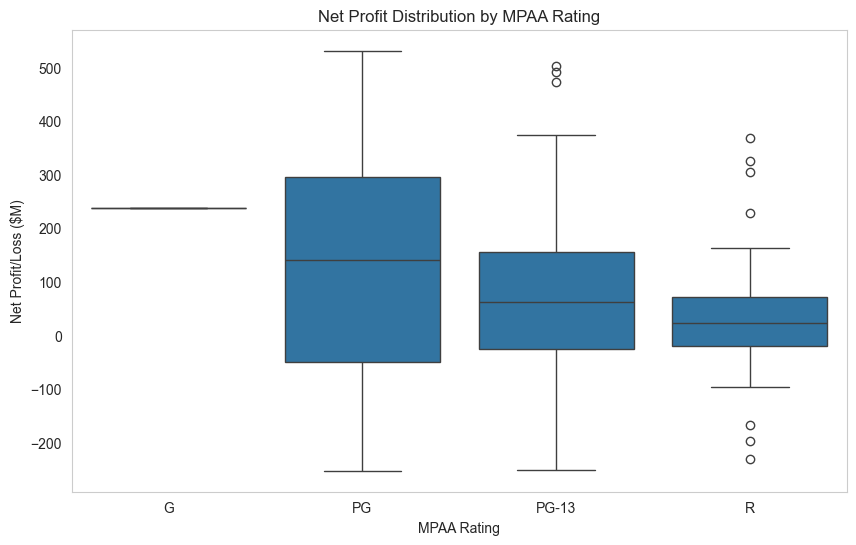

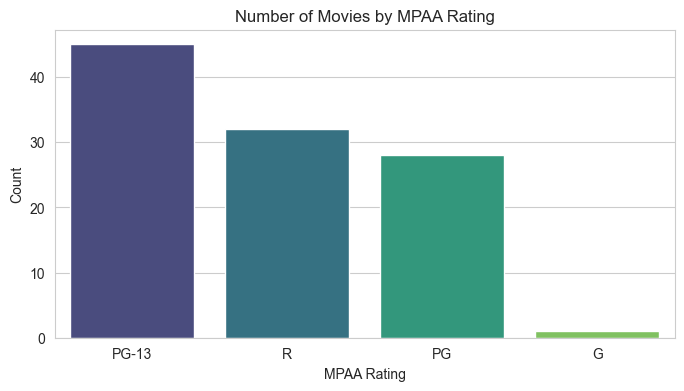

In [17]:

plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x='MPAA Rating', y='Net Profit/Loss ($M)', order=['G', 'PG', 'PG-13', 'R'])
plt.title('Net Profit Distribution by MPAA Rating')
plt.xlabel('MPAA Rating')
plt.ylabel('Net Profit/Loss ($M)')
plt.grid(axis='y')
plt.show()


rating_counts = df_clean['MPAA Rating'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    hue=rating_counts.index,
    palette='viridis',
    legend=False
)
plt.title('Number of Movies by MPAA Rating')
plt.ylabel('Count')
plt.show()

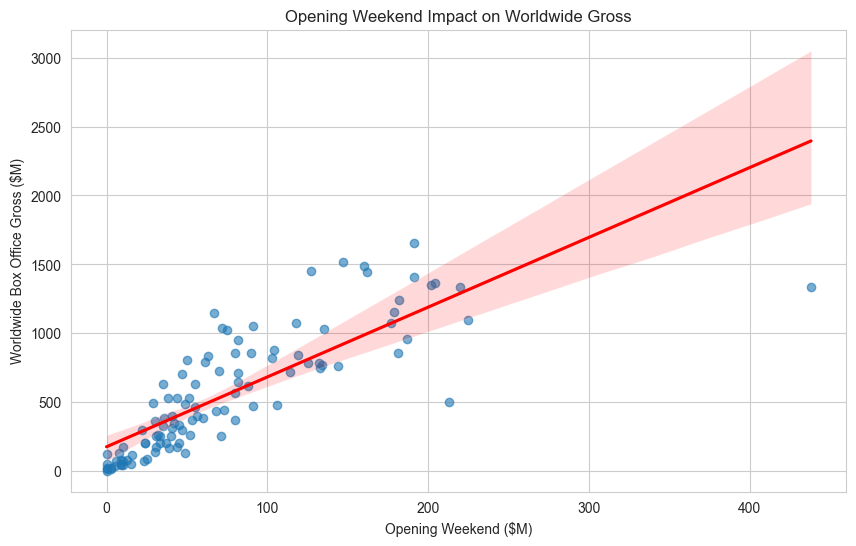

In [18]:

plt.figure(figsize=(10,6))
sns.regplot(data=df_clean, x='Opening Weekend ($M)', y='WW Box Office Gross ($M)', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Opening Weekend Impact on Worldwide Gross')
plt.xlabel('Opening Weekend ($M)')
plt.ylabel('Worldwide Box Office Gross ($M)')
plt.grid(True)
plt.show()

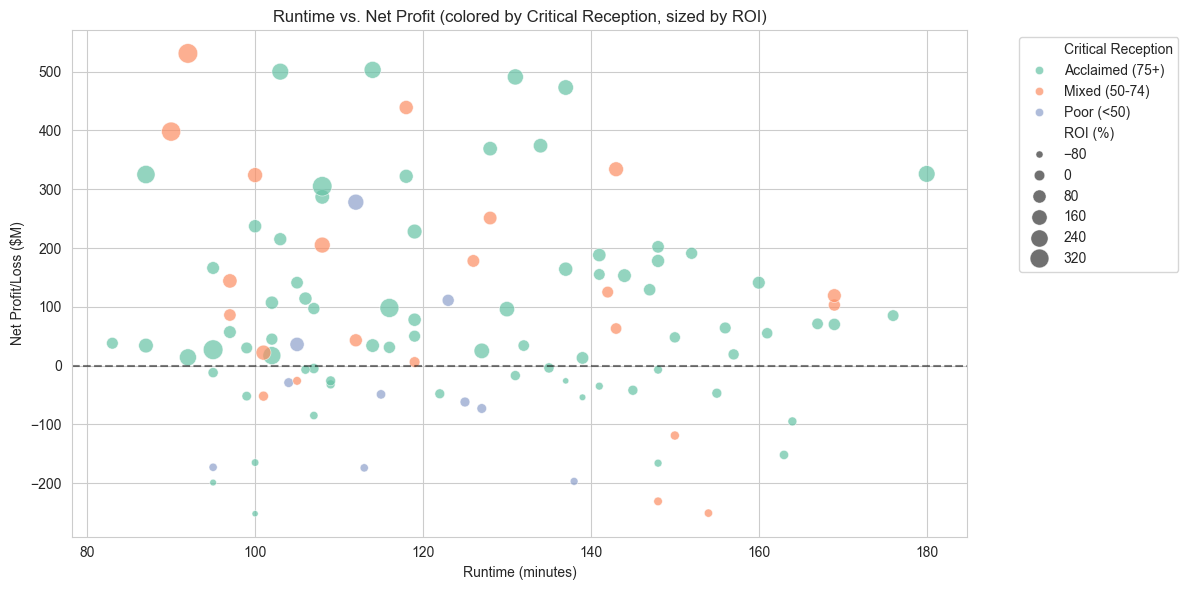

In [19]:
plt.figure(figsize=(12,6))
scatter = sns.scatterplot(data=df_clean, x='Runtime (min)', y='Net Profit/Loss ($M)',
                          hue='Critical Reception', size='ROI (%)', sizes=(20,200),
                          palette='Set2', alpha=0.7)
plt.title('Runtime vs. Net Profit (colored by Critical Reception, sized by ROI)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Net Profit/Loss ($M)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

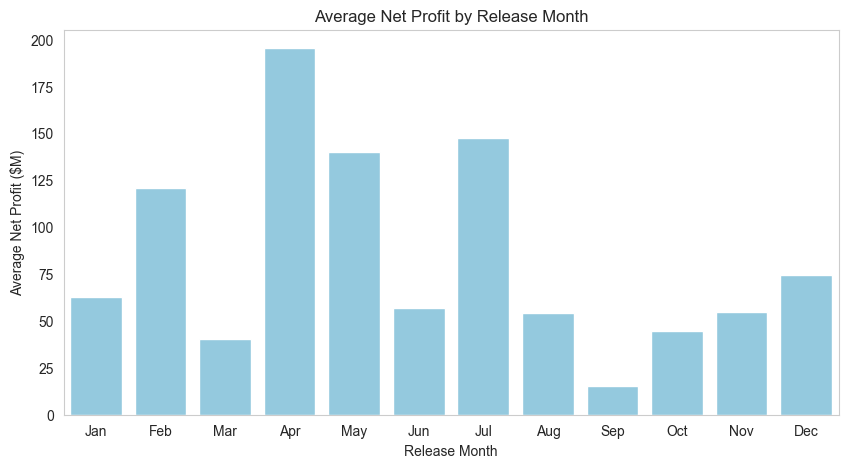

In [20]:
monthly_profit = df_clean.groupby('Release Month')['Net Profit/Loss ($M)'].mean().reset_index()

all_months = pd.DataFrame({'Release Month': range(1,13)})
monthly_profit = all_months.merge(monthly_profit, on='Release Month', how='left')

plt.figure(figsize=(10,5))
sns.barplot(
    data=monthly_profit,
    x='Release Month',
    y='Net Profit/Loss ($M)',
    color='skyblue'
)

plt.title('Average Net Profit by Release Month')
plt.xlabel('Release Month')
plt.ylabel('Average Net Profit ($M)')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y')
plt.show()